# Đánh giá kết quả huấn luyện

Notebook này xem lại các mô hình đã huấn luyện, gồm hai phần:

1. Ba mô hình sau 15 epoch: SSDLite320, YOLO11s, D-FINE-N.
2. YOLO11s huấn luyện dài hơn, cấu hình 80 epoch.

Mỗi phần có bảng số liệu, kết quả chạy trên cùng một nhóm ảnh, và nhận xét.
Tập test gồm 310 ảnh lấy từ COCO val2017, không tham gia huấn luyện.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.config import DISPLAY_SCORE_THRESHOLD, MODELS, RUNS_DIR
from src.data.coco_dataset import CocoRecords
from src.evaluation.coco_eval import evaluate_detections
from src.evaluation.figures import draw_boxes
from src.models.loader import load_trained

# src.evaluation.figures dat backend "Agg"; tra ve inline de hinh hien trong notebook.
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = DISPLAY_SCORE_THRESHOLD
test = CocoRecords("test")

# Bon cau hinh can xem: ba mo hinh 15 epoch, va YOLO huan luyen dai hon.
CONFIGS = {
    "SSDLite320 (15 ep)": ("ssdlite", RUNS_DIR / "ssdlite" / "last.pt"),
    "YOLO11s (15 ep)": ("yolo11s", RUNS_DIR / "yolo11s" / "weights" / "last.pt"),
    "D-FINE-N (15 ep)": ("dfine", RUNS_DIR / "dfine" / "last.pt"),
    "YOLO11s (64 ep)": ("yolo11s", RUNS_DIR / "yolo11s_deep" / "weights" / "last.pt"),
}

print("Tap test:", len(test), "anh |", device)

Tap test: 310 anh | cuda


## Thông tin các lượt huấn luyện

Số liệu lấy từ `history.json` của từng lượt.

In [2]:
RUN_DIRS = {
    "SSDLite320 (15 ep)": "ssdlite",
    "YOLO11s (15 ep)": "yolo11s",
    "D-FINE-N (15 ep)": "dfine",
    "YOLO11s (64 ep)": "yolo11s_deep",
}

rows = []
for label, run in RUN_DIRS.items():
    h = json.loads((RUNS_DIR / run / "history.json").read_text(encoding="utf-8"))
    vals = [(e["epoch"], e.get("val_mAP_50_95", e.get("metrics/mAP50-95(B)")))
            for e in h["epochs"]]
    vals = [(a, b) for a, b in vals if b is not None]
    best_ep, best_val = max(vals, key=lambda x: x[1])
    key = RUN_DIRS[label] if RUN_DIRS[label] != "yolo11s_deep" else "yolo11s"
    rows.append({
        "mo hinh": label,
        "ho kien truc": MODELS[key]["family"],
        "tham so": f"{MODELS[key].get('params', 0):,}" if False else None,
        "epoch chay": len(vals),
        "epoch tot nhat": best_ep,
        "val mAP tot nhat": round(best_val, 4),
        "val mAP epoch cuoi": round(vals[-1][1], 4),
        "thoi gian train (phut)": round(h["totals"]["train_seconds"] / 60, 1),
    })

train_table = pd.DataFrame(rows).drop(columns=["tham so"])
train_table

,mo hinh,ho kien truc,epoch chay,epoch tot nhat,val mAP tot nhat,val mAP epoch cuoi,thoi gian train (phut)
0,SSDLite320 (15 ep),"CNN (one-stage, anchor-based)",15,13,0.1514,0.1509,29.7
1,YOLO11s (15 ep),"YOLO (one-stage, anchor-free)",15,15,0.2883,0.2883,24.5
2,D-FINE-N (15 ep),"Transformer (DETR-based, end-to-end)",15,1,0.1277,0.0593,42.2
3,YOLO11s (64 ep),"YOLO (one-stage, anchor-free)",64,44,0.2904,0.2859,89.7


## Chấm điểm trên tập test

Cả bốn cấu hình đi qua cùng một bộ đo `pycocotools`, trên cùng tập test.
Bước này chạy suy luận trên 310 ảnh cho mỗi cấu hình nên mất vài phút.

In [3]:
def detect_split(model_key, weights):
    """Chay mot checkpoint tren toan bo tap test, tra ve danh sach COCO detections."""
    loaded = load_trained(model_key, weights=weights, device="auto")
    if loaded.framework == "torchvision":
        from src.evaluation.predict import predict_ssdlite
        det, _ = predict_ssdlite(loaded.model, split="test", device=device,
                                 batch_size=16, workers=2)
    elif loaded.framework == "ultralytics":
        from src.evaluation.predict import predict_yolo
        det, _ = predict_yolo(loaded.model, split="test", imgsz=loaded.imgsz,
                              device=0 if device.type == "cuda" else "cpu", batch_size=16)
    else:
        from src.evaluation.predict import predict_dfine
        det, _ = predict_dfine(loaded.model, loaded.processor, split="test",
                               device=device, batch_size=16, workers=2)
    del loaded
    torch.cuda.empty_cache()
    return det


scores = {}
for label, (key, weights) in CONFIGS.items():
    det = detect_split(key, weights)
    m = evaluate_detections(det, split="test", verbose=False)
    scores[label] = {
        "mAP@[.5:.95]": round(m["mAP_50_95"], 4),
        "mAP@.5": round(m["mAP_50"], 4),
        "mAP@.75": round(m["mAP_75"], 4),
        "AR@100": round(m["AR_max100"], 4),
        "AP nho": round(m["mAP_small"], 4),
        "AP trung binh": round(m["mAP_medium"], 4),
        "AP lon": round(m["mAP_large"], 4),
    }
    print(f"{label:<20} mAP={m['mAP_50_95']:.4f}", flush=True)

test_table = pd.DataFrame(scores).T
test_table

SSDLite320 (15 ep)   mAP=0.1237


YOLO11s (15 ep)      mAP=0.2569


C:\Users\KUONG\miniconda3\envs\objdet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `80`.



Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

...


Loading weights: 100%|██████████| 644/644 [00:00<00:00, 4199.98it/s]


[transformers] DFineForObjectDetection LOAD REPORT from: ustc-community/dfine-nano-coco
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 128]) vs model:torch.Size([5, 128])
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.enc_score_head.weight                | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 128]) vs model:torch.Size([5, 128])
model.denoising_class_embed.weight         | MI

D-FINE-N (15 ep)     mAP=0.0447


YOLO11s (64 ep)      mAP=0.2714


,mAP@[.5:.95],mAP@.5,mAP@.75,AR@100,AP nho,AP trung binh,AP lon
SSDLite320 (15 ep),0.1237,0.2303,0.1178,0.2721,0.0014,0.0801,0.3210
YOLO11s (15 ep),0.2569,0.3999,0.2708,0.5545,0.0778,0.2867,0.3957
D-FINE-N (15 ep),0.0447,0.0903,0.0391,0.4527,0.0135,0.0850,0.0715
YOLO11s (64 ep),0.2714,0.4103,0.2865,0.5552,0.0811,0.3089,0.4100


## 1. Ba mô hình sau 15 epoch

### 1.1 Số liệu

In [4]:
first_three = list(CONFIGS)[:3]
test_table.loc[first_three]

,mAP@[.5:.95],mAP@.5,mAP@.75,AR@100,AP nho,AP trung binh,AP lon
SSDLite320 (15 ep),0.1237,0.2303,0.1178,0.2721,0.0014,0.0801,0.3210
YOLO11s (15 ep),0.2569,0.3999,0.2708,0.5545,0.0778,0.2867,0.3957
D-FINE-N (15 ep),0.0447,0.0903,0.0391,0.4527,0.0135,0.0850,0.0715


### 1.2 Kết quả trên vài ảnh

Ảnh được chọn theo tiêu chí cố định: có từ 2 đến 15 vật thể, kích thước vật thể
ở mức thông thường. Ngưỡng hiển thị là 0.35.

In [5]:
def median_rel_area(i):
    r = test.records[i]
    areas = [(a["bbox"][2] * a["bbox"][3]) / (r["width"] * r["height"])
             for a in r["annotations"]]
    return float(np.median(areas)) if areas else 0.0


candidates = sorted(
    (i for i in range(len(test))
     if 2 <= len(test.records[i]["annotations"]) <= 15 and median_rel_area(i) > 0.02),
    key=lambda i: len(test.records[i]["annotations"]),
)
picks = [candidates[int(p * len(candidates))] for p in (0.25, 0.55, 0.85)]
images = [test.image(i) for i in picks]
paths = [str(test.path(i)) for i in picks]
sizes = [(test.records[i]["height"], test.records[i]["width"]) for i in picks]
print("Anh:", [test.records[i]["file_name"] for i in picks])

Anh: ['000000537506.jpg', '000000350388.jpg', '000000335427.jpg']


In [6]:
def to_records(boxes_xyxy, scores_list, class_ids):
    out = []
    for (x0, y0, x1, y1), s, c in zip(boxes_xyxy, scores_list, class_ids):
        if s < THRESHOLD:
            continue
        out.append({"bbox": [float(x0), float(y0), float(x1 - x0), float(y1 - y0)],
                    "category_id": int(c), "score": float(s)})
    return out


def detect_images(model_key, weights):
    """Chay mot checkpoint tren dung ba anh da chon."""
    loaded = load_trained(model_key, weights=weights, device="auto")
    result = []

    if loaded.framework == "torchvision":
        from torchvision.transforms.functional import to_tensor
        with torch.no_grad():
            outs = loaded.model([to_tensor(im).to(device) for im in images])
        result = [to_records(o["boxes"].cpu().tolist(), o["scores"].cpu().tolist(),
                             o["labels"].cpu().tolist()) for o in outs]

    elif loaded.framework == "ultralytics":
        res = loaded.model.predict(paths, imgsz=loaded.imgsz, conf=THRESHOLD, verbose=False,
                                   device=0 if device.type == "cuda" else "cpu")
        result = [to_records(r.boxes.xyxy.cpu().tolist(), r.boxes.conf.cpu().tolist(),
                             [int(c) + 1 for c in r.boxes.cls.cpu().tolist()]) for r in res]

    else:
        enc = loaded.processor(images=[np.asarray(im) for im in images], return_tensors="pt")
        with torch.no_grad():
            out = loaded.model(pixel_values=enc["pixel_values"].to(device))
        proc = loaded.processor.post_process_object_detection(
            out, threshold=THRESHOLD, target_sizes=torch.tensor(sizes, device=device))
        result = [to_records(p["boxes"].cpu().tolist(), p["scores"].cpu().tolist(),
                             [int(c) + 1 for c in p["labels"].cpu().tolist()]) for p in proc]

    del loaded
    torch.cuda.empty_cache()
    return result


detections = {label: detect_images(key, w) for label, (key, w) in CONFIGS.items()}
print("Xong", len(detections), "cau hinh")

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `80`.



Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]


Loading weights:  82%|████████▏ | 531/644 [00:00<00:00, 5273.17it/s]


Loading weights: 100%|██████████| 644/644 [00:00<00:00, 5191.03it/s]


[transformers] DFineForObjectDetection LOAD REPORT from: ustc-community/dfine-nano-coco
Key                                        | Status   |                                                                                        
-------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 128]) vs model:torch.Size([5, 128])
model.enc_score_head.bias                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.decoder.class_embed.{0, 1, 2}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([5])          
model.enc_score_head.weight                | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 128]) vs model:torch.Size([5, 128])
model.denoising_class_embed.weight         | MI

C:\Users\KUONG\miniconda3\envs\objdet\Lib\site-packages\transformers\image_processing_backends.py:135: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  image = torch.from_numpy(image).contiguous()


Xong 4 cau hinh


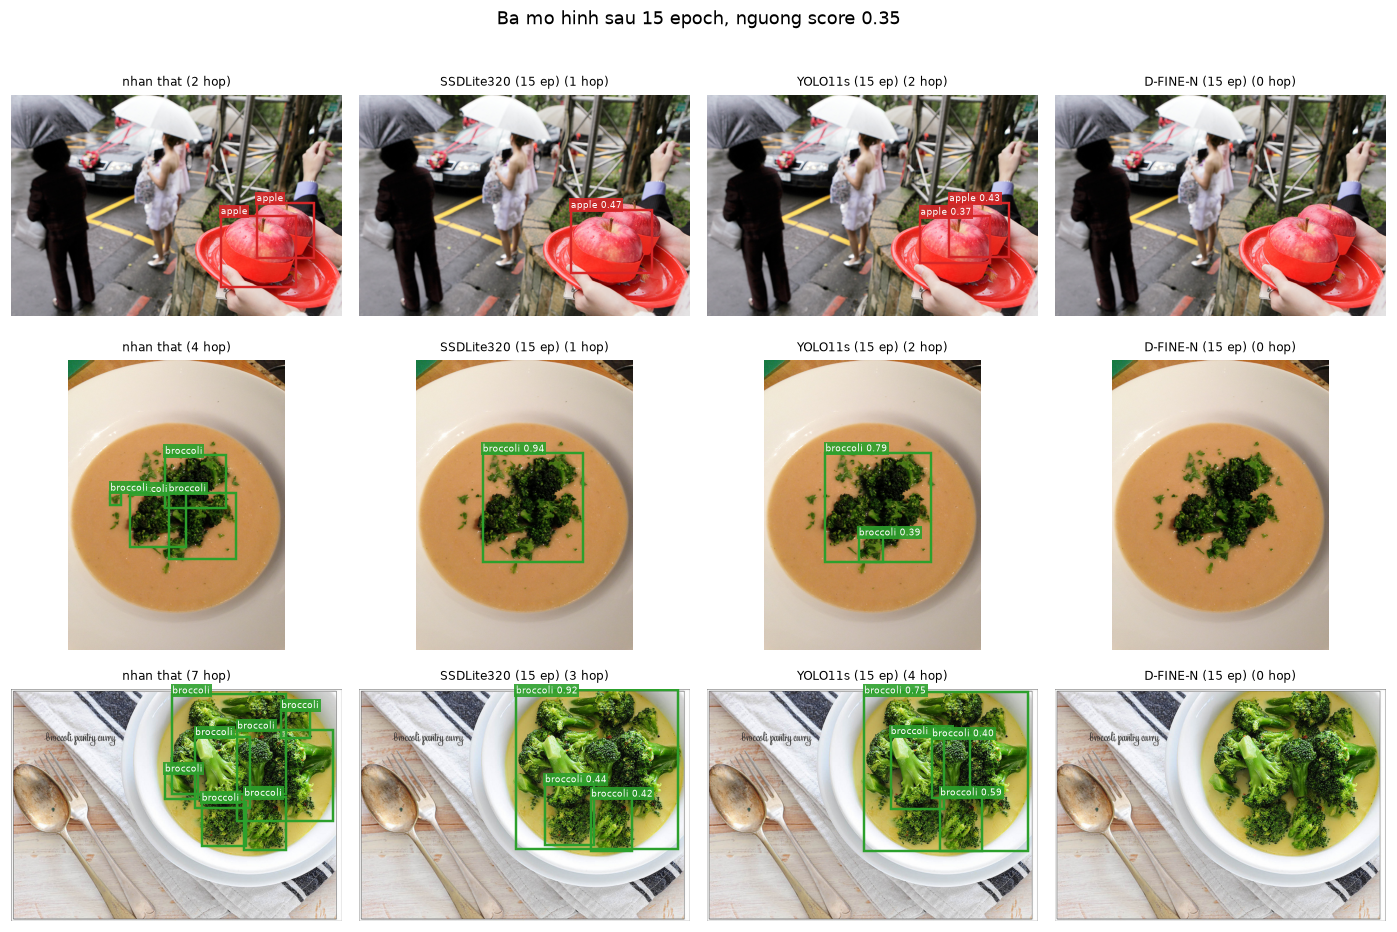

In [7]:
def show(labels, title):
    fig, axes = plt.subplots(len(picks), 1 + len(labels),
                             figsize=(3.2 * (1 + len(labels)), 2.9 * len(picks)))
    axes = np.atleast_2d(axes)
    for row, idx in enumerate(picks):
        truth = [{"bbox": a["bbox"], "category_id": a["category_id"]}
                 for a in test.records[idx]["annotations"]]
        draw_boxes(axes[row][0], images[row], truth, f"nhan that ({len(truth)} hop)")
        for col, label in enumerate(labels, start=1):
            found = detections[label][row]
            draw_boxes(axes[row][col], images[row], found, f"{label} ({len(found)} hop)")
    fig.suptitle(title, y=0.999)
    fig.tight_layout()
    plt.show()


show(first_three, f"Ba mo hinh sau 15 epoch, nguong score {THRESHOLD}")

In [8]:
pd.DataFrame(
    {"nhan that": [len(test.records[i]["annotations"]) for i in picks],
     **{label: [len(detections[label][r]) for r in range(len(picks))]
        for label in first_three}},
    index=[test.records[i]["file_name"] for i in picks],
)

,nhan that,SSDLite320 (15 ep),YOLO11s (15 ep),D-FINE-N (15 ep)
000000537506.jpg,2,1,2,0
000000350388.jpg,4,1,2,0
000000335427.jpg,7,3,4,0


### 1.3 Nhận xét

SSDLite320 và YOLO11s đưa ra số hộp ít hơn nhãn thật ở những ảnh có nhiều vật thể
nhỏ nằm sát nhau. Cả hai gom một cụm thành một hộp lớn thay vì tách từng vật thể.
Điều này khớp với cột "AP nhỏ" trong bảng số liệu: SSDLite chỉ đạt 0.0014 ở nhóm
vật thể nhỏ, do đầu vào của nó bị cố định ở 320×320, nhỏ hơn bốn lần diện tích so
với 640×640 của hai mô hình còn lại.

D-FINE-N không đưa ra hộp nào vượt ngưỡng 0.35. Đây không phải do mô hình không
dự đoán gì, mà do toàn bộ điểm tin cậy của nó đều thấp: giá trị cao nhất trên cả
310 ảnh test là 0.334. Chỉ số AR@100 của nó vẫn ở mức 0.4527, cao hơn SSDLite,
nghĩa là nó vẫn tìm đúng vùng có vật thể nhưng không chấm điểm cao cho chúng.

Khoảng cách giữa AR@100 và mAP là dấu hiệu rõ nhất. Với SSDLite và YOLO11s, tỉ lệ
này khoảng 2 lần, là mức thông thường. Với D-FINE-N, tỉ lệ lên tới 10 lần.

## 2. YOLO11s huấn luyện dài hơn

Lượt này được cấu hình 80 epoch nhưng dừng ở epoch 64. Ultralytics có cơ chế
`patience=20`, dừng khi val mAP không cải thiện trong 20 epoch liên tiếp; đỉnh rơi
vào epoch 44 nên điều kiện được kích hoạt ở epoch 64.

### 2.1 Số liệu

In [9]:
yolo_rows = ["YOLO11s (15 ep)", "YOLO11s (64 ep)"]
compare = test_table.loc[yolo_rows].copy()
compare["thoi gian train (phut)"] = [
    train_table.set_index("mo hinh").loc[r, "thoi gian train (phut)"] for r in yolo_rows
]
compare

,mAP@[.5:.95],mAP@.5,mAP@.75,AR@100,AP nho,AP trung binh,AP lon,thoi gian train (phut)
YOLO11s (15 ep),0.2569,0.3999,0.2708,0.5545,0.0778,0.2867,0.3957,24.5
YOLO11s (64 ep),0.2714,0.4103,0.2865,0.5552,0.0811,0.3089,0.4100,89.7


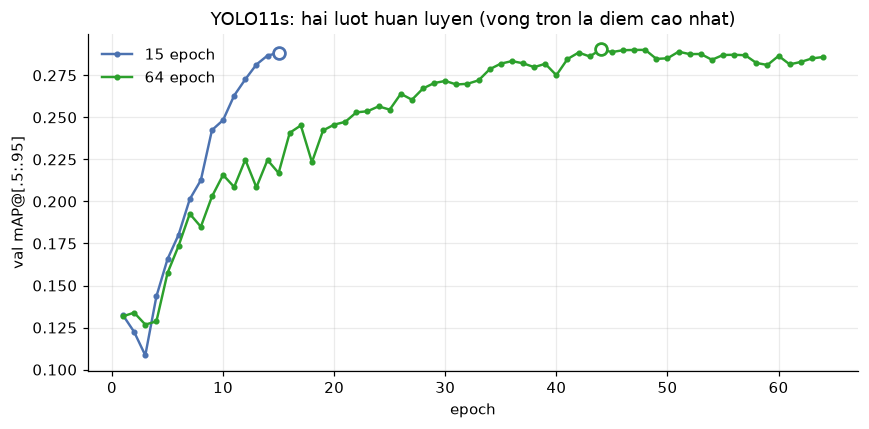

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for run, label, color in (("yolo11s", "15 epoch", "#4c72b0"),
                          ("yolo11s_deep", "64 epoch", "#2ca02c")):
    h = json.loads((RUNS_DIR / run / "history.json").read_text(encoding="utf-8"))
    xs = [e["epoch"] for e in h["epochs"]]
    ys = [e["metrics/mAP50-95(B)"] for e in h["epochs"]]
    ax.plot(xs, ys, marker="o", markersize=3, linewidth=1.6, color=color, label=label)
    ax.scatter([xs[ys.index(max(ys))]], [max(ys)], s=60, zorder=5,
               facecolor="white", edgecolor=color, linewidth=1.8)

ax.set_xlabel("epoch")
ax.set_ylabel("val mAP@[.5:.95]")
ax.set_title("YOLO11s: hai luot huan luyen (vong tron la diem cao nhat)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 2.2 Kết quả trên cùng nhóm ảnh

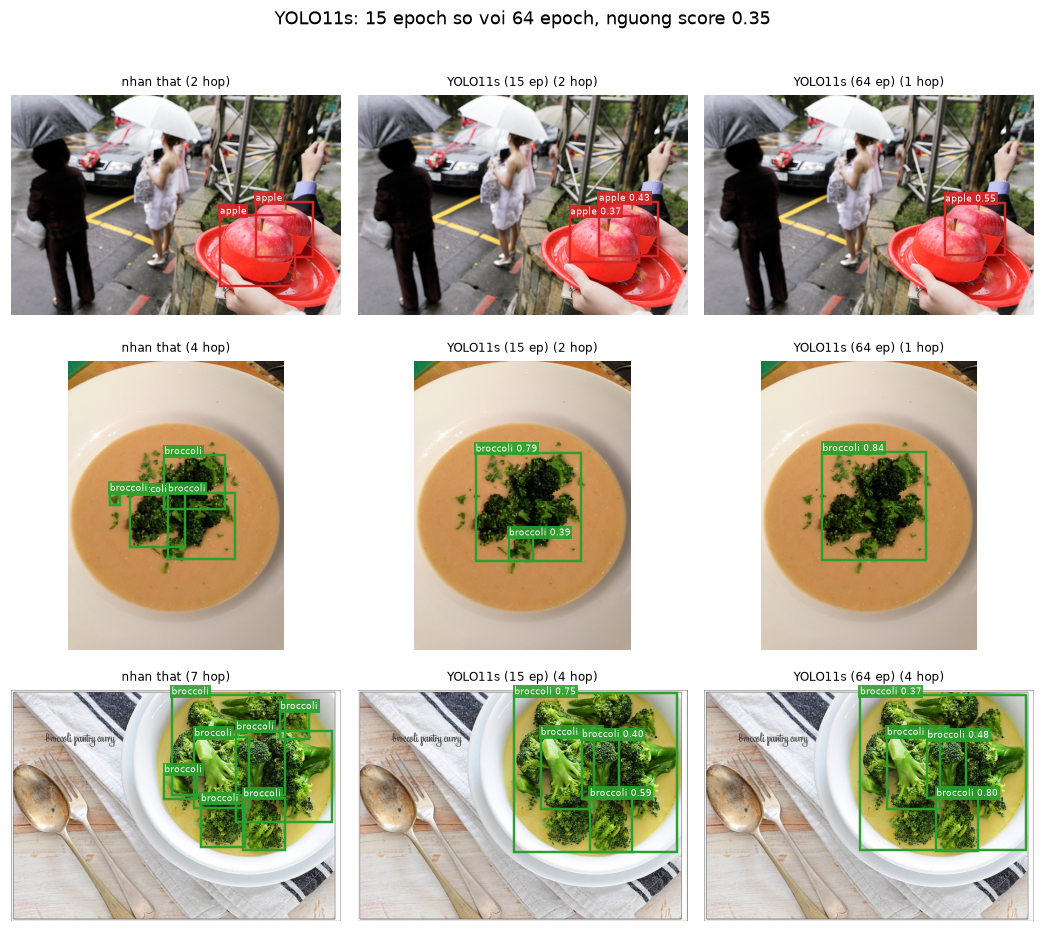

In [11]:
show(yolo_rows, f"YOLO11s: 15 epoch so voi 64 epoch, nguong score {THRESHOLD}")

In [12]:
pd.DataFrame(
    {"nhan that": [len(test.records[i]["annotations"]) for i in picks],
     **{label: [len(detections[label][r]) for r in range(len(picks))] for label in yolo_rows}},
    index=[test.records[i]["file_name"] for i in picks],
)

,nhan that,YOLO11s (15 ep),YOLO11s (64 ep)
000000537506.jpg,2,2,1
000000350388.jpg,4,2,1
000000335427.jpg,7,4,4


Hai tập cho hai bức tranh khác nhau, và chỗ này đáng chú ý.

Trên tập val, huấn luyện thêm 49 epoch chỉ đưa mAP từ 0.2883 lên 0.2904, tức 0.0021.
Nhìn vào riêng con số này thì phần thời gian tăng thêm (24.5 phút lên 89.7 phút)
gần như không mang lại gì. Đường cong ở mục 2.1 củng cố cách đọc đó: từ khoảng
epoch 44 trở đi, giá trị dao động trong khoảng 0.284 đến 0.290 mà không lập đỉnh mới.

Nhưng trên tập test, chênh lệch là 0.2569 lên 0.2714, tức 0.0145, gấp bảy lần mức
cải thiện trên val.

Nguyên nhân nằm ở cách chia dữ liệu. Tập train và val đều được cắt ra từ COCO
train2017, còn tập test lấy từ COCO val2017, một đợt thu thập khác. Val vì vậy
không độc lập với train về phân phối. Trong 20 epoch cuối, val mAP đứng yên nhưng
mô hình vẫn tiếp tục thay đổi theo hướng khái quát hơn, và phần thay đổi đó chỉ đo
được trên tập test.

Điều này cũng có nghĩa: nếu chỉ theo dõi val mAP để quyết định dừng huấn luyện thì
sẽ dừng sớm hơn mức tối ưu. Cơ chế `patience=20` đã dừng lượt này ở epoch 64 dựa
trên val, trong khi tập test cho thấy phần huấn luyện sau epoch 44 vẫn có tác dụng.

Trên ba ảnh mẫu, hai phiên bản cho kết quả gần giống nhau. Chênh lệch 0.0145 mAP là
quá nhỏ để nhìn thấy bằng mắt trên một vài tấm ảnh.